In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

import joblib

In [2]:
df= pd.read_excel('banking_dataset.xlsx')
df.head()

,customer_id,age,gender,income,employment_type,loan_amount,loan_tenure,credit_score,existing_debt,city,account_balance,transaction_count,defaulted
0,1001,44,Female,70466,Salaried,747640,8,678,147938,Pune,457072,39,0
1,1002,38,Male,52627,Self-employed,1176523,17,659,449640,Hyderabad,430464,125,1
2,1003,29,Male,145999,Self-employed,848986,6,523,139648,Hyderabad,21442,6,1
3,1004,53,Female,85976,Self-employed,588719,16,610,116950,Mumbai,459395,98,0
4,1005,59,Female,100820,Salaried,704122,20,713,174909,Nashik,470811,113,0


# check data information


In [3]:
df.shape

(1000, 13)

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   customer_id        1000 non-null   int64
 1   age                1000 non-null   int64
 2   gender             1000 non-null   str  
 3   income             1000 non-null   int64
 4   employment_type    1000 non-null   str  
 5   loan_amount        1000 non-null   int64
 6   loan_tenure        1000 non-null   int64
 7   credit_score       1000 non-null   int64
 8   existing_debt      1000 non-null   int64
 9   city               1000 non-null   str  
 10  account_balance    1000 non-null   int64
 11  transaction_count  1000 non-null   int64
 12  defaulted          1000 non-null   int64
dtypes: int64(10), str(3)
memory usage: 101.7 KB


In [5]:
df.describe()

,customer_id,age,income,loan_amount,loan_tenure,credit_score,existing_debt,account_balance,transaction_count,defaulted
count,1000.000000,1000.000000,1000.000000,1.000000e+03,1000.000000,1000.000000,1000.00000,1000.00000,1000.00000,1000.000000
mean,1500.500000,40.778000,88570.806000,7.887805e+05,10.403000,653.678000,255931.37800,253741.64800,77.42500,0.604000
std,288.819436,11.325855,35703.647152,4.179202e+05,5.766094,119.558256,144416.40527,143780.72486,43.01333,0.489309
min,1001.000000,21.000000,25099.000000,5.057100e+04,1.000000,450.000000,636.00000,5104.00000,5.00000,0.000000
25%,1250.750000,32.000000,59346.000000,4.364978e+05,5.000000,548.000000,130652.00000,134976.25000,40.00000,0.000000
50%,1500.500000,41.000000,88550.000000,7.895450e+05,10.000000,648.000000,260734.50000,250452.00000,77.50000,1.000000
75%,1750.250000,50.250000,120130.750000,1.159244e+06,15.000000,761.000000,385321.00000,377858.00000,116.00000,1.000000
max,2000.000000,60.000000,149736.000000,1.498982e+06,20.000000,850.000000,499466.00000,499984.00000,150.00000,1.000000


# data cleaning

In [6]:
df.isnull().sum()

#print(df.duplicated().sum())
#df.drop_duplicates(inplace=True)
# Removes repeated customer records.

customer_id          0
age                  0
gender               0
income               0
employment_type      0
loan_amount          0
loan_tenure          0
credit_score         0
existing_debt        0
city                 0
account_balance      0
transaction_count    0
defaulted            0
dtype: int64

In [7]:
encoder = LabelEncoder()

categorical_columns = [
    'gender',
    'employment_type',
    'city'
]

for col in categorical_columns:
    df[col] = encoder.fit_transform(df[col])

print(df.head())

# convert text in to number

   customer_id  age  gender  income  employment_type  loan_amount  \
0         1001   44       0   70466                0       747640   
1         1002   38       1   52627                1      1176523   
2         1003   29       1  145999                1       848986   
3         1004   53       0   85976                1       588719   
4         1005   59       0  100820                0       704122   

   loan_tenure  credit_score  existing_debt  city  account_balance  \
0            8           678         147938     7           457072   
1           17           659         449640     3           430464   
2            6           523         139648     3            21442   
3           16           610         116950     4           459395   
4           20           713         174909     6           470811   

   transaction_count  defaulted  
0                 39          0  
1                125          1  
2                  6          1  
3                 98        

In [8]:
df.head()

,customer_id,age,gender,income,employment_type,loan_amount,loan_tenure,credit_score,existing_debt,city,account_balance,transaction_count,defaulted
0,1001,44,0,70466,0,747640,8,678,147938,7,457072,39,0
1,1002,38,1,52627,1,1176523,17,659,449640,3,430464,125,1
2,1003,29,1,145999,1,848986,6,523,139648,3,21442,6,1
3,1004,53,0,85976,1,588719,16,610,116950,4,459395,98,0
4,1005,59,0,100820,0,704122,20,713,174909,6,470811,113,0


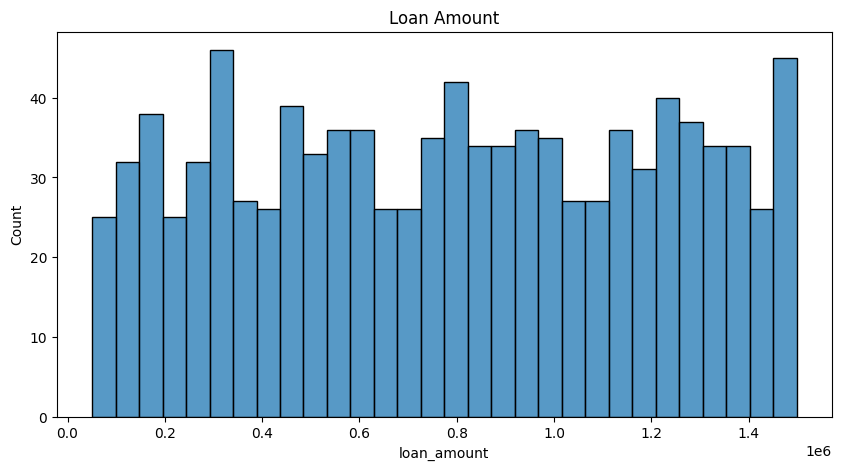

In [9]:
#  Which loan amounts are most common

plt.figure(figsize=(10,5))
sns.histplot(df['loan_amount'],bins=30)
plt.title('Loan Amount')
plt.show()



In [10]:
a=df.groupby('age')['gender'].sum()
a

age
21    12
22    12
23    12
24     5
25     8
26    13
27    14
28    13
29    15
30    15
31    11
32     7
33    16
34    13
35    11
36    12
37    16
38    16
39    11
40     9
41    17
42    19
43    14
44    11
45    12
46    18
47     9
48    10
49     8
50     9
51    16
52     8
53    12
54    16
55    13
56     8
57     7
58    12
59    14
60    14
Name: gender, dtype: int32

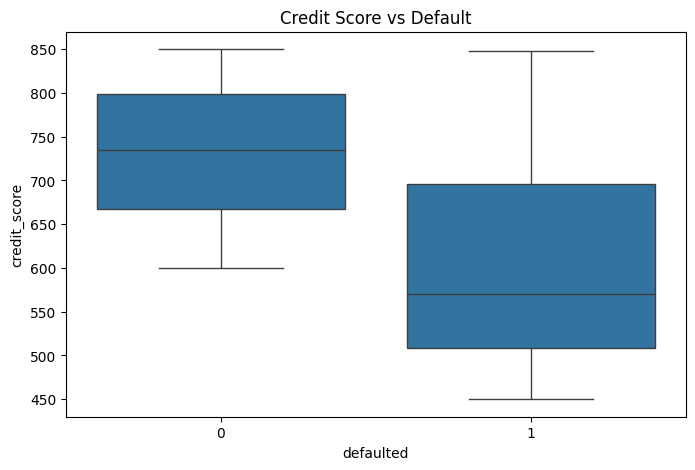

In [11]:
# Credit Score vs Default 

plt.figure(figsize=(8,5))

sns.boxplot(
    x='defaulted',
    y='credit_score',
    data=df)

plt.title('Credit Score vs Default')

plt.show()

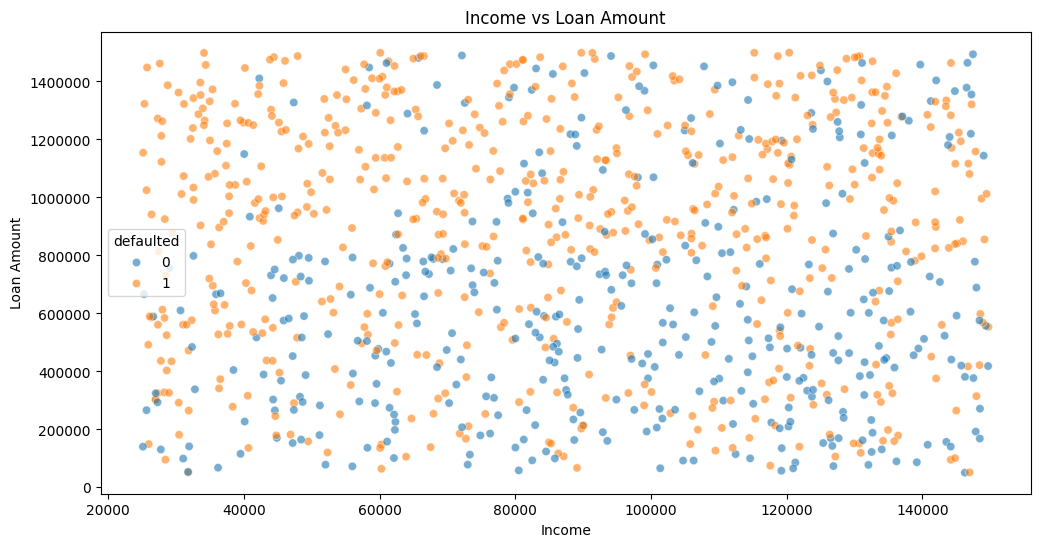

In [12]:
# income vs loan amount 

plt.figure(figsize=(12,6))

sns.scatterplot(
    x='income',
    y='loan_amount',
    hue='defaulted',
    data=df,
    alpha=0.6
)

plt.ticklabel_format(style='plain', axis='y')

plt.title("Income vs Loan Amount")
plt.xlabel("Income")
plt.ylabel("Loan Amount")

plt.show()



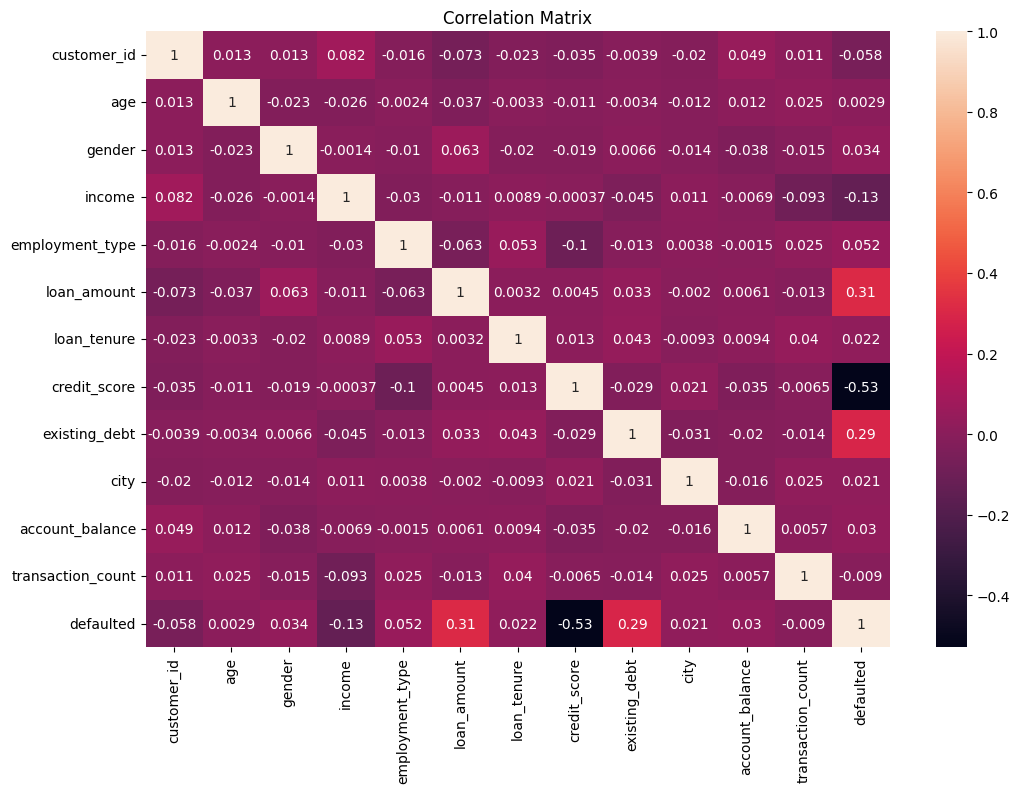

In [13]:
# corelation 

plt.figure(figsize=(12,8))

sns.heatmap(
    df.corr(),
    annot=True  # heat map color show karto ani ha number show karto  
)

plt.title('Correlation Matrix')

plt.show()



# graph : income vs loan_amount = 0.82  strongly relation , 1 self relation, -0.01 and more nigative values are almost no ralation

In [14]:
# future relation

X = df.drop(
    ['customer_id', 'defaulted'],
    axis=1
)

y = df['defaulted']

In [15]:
# train ans split test

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [16]:
# train machine learning model

model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [17]:
# prediction

predictions = model.predict(X_test)

In [18]:
# Accuracy

accuracy = accuracy_score(
    y_test,
    predictions
)

print("Accuracy:", accuracy)

Accuracy: 1.0


In [19]:
# classification report

print(
    classification_report(
        y_test,
        predictions
    )
)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        90
           1       1.00      1.00      1.00       110

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200



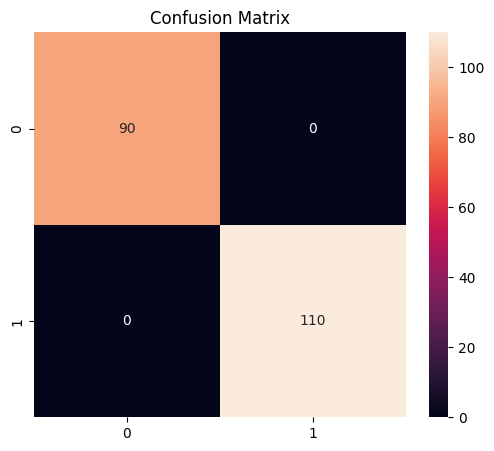

In [20]:
# Confisiooon Matrix 

cm = confusion_matrix(
    y_test,
    predictions
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d'
)

plt.title('Confusion Matrix')

plt.show()

In [21]:
# Feature Importance

importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

importance

,Feature,Importance
6,credit_score,0.413751
4,loan_amount,0.209613
7,existing_debt,0.190671
2,income,0.075952
9,account_balance,0.025534
10,transaction_count,0.023854
5,loan_tenure,0.020650
0,age,0.017975
8,city,0.013181
3,employment_type,0.004423


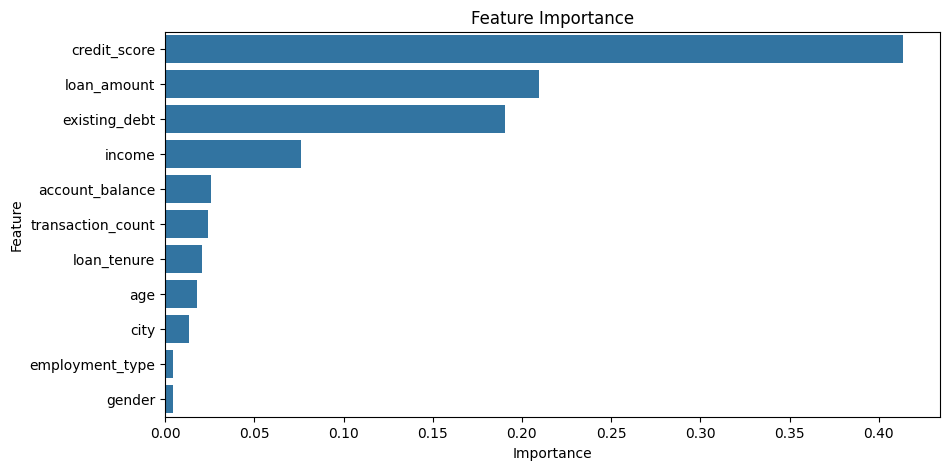

In [24]:
# feature importance graph

plt.figure(figsize=(10,5))

sns.barplot(
    x='Importance',
    y='Feature',
    data=importance
)

plt.title('Feature Importance')

plt.show()

In [26]:
# save model

joblib.dump(
    model,
    'loan_model.pkl'
)


['loan_model.pkl']

In [28]:
# load save model

loaded_model = joblib.load(
    'loan_model.pkl'
)

In [33]:
# predict new coustomer

sample_data = pd.DataFrame({
    'age': [35],
    'gender': [1],
    'income': [50000],
    'employment_type': [1],
    'loan_amount': [300000],
    'loan_tenure': [5],
    'credit_score': [700],
    'existing_debt': [100000],
    'city': [2],
    'account_balance': [50000],
    'transaction_count': [40]
})

prediction = loaded_model.predict(sample_data)

print(prediction)

[0]


In [35]:
# export clean data 
df.to_csv('clean_banking_dataset.csv ', index=False)